<a href="https://colab.research.google.com/github/kavinraajs04/NLP_Projects/blob/main/Project_2_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
!pip install nltk wordcloud scikit-learn seaborn

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import nltk
import re
import seaborn as sns

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from wordcloud import WordCloud

In [40]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [41]:
df = pd.read_csv("/content/Restaurant reviews.csv")

df.head()

,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures,7514
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5,"1 Review , 2 Followers",5/25/2019 15:54,0,2447.0
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5,"3 Reviews , 2 Followers",5/25/2019 14:20,0,NaN
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5,"2 Reviews , 3 Followers",5/24/2019 22:54,0,NaN
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5,"1 Review , 1 Follower",5/24/2019 22:11,0,NaN
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5,"3 Reviews , 2 Followers",5/24/2019 21:37,0,NaN


In [42]:
df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Restaurant  10000 non-null  object 
 1   Reviewer    9962 non-null   object 
 2   Review      9955 non-null   object 
 3   Rating      9962 non-null   object 
 4   Metadata    9962 non-null   object 
 5   Time        9962 non-null   object 
 6   Pictures    10000 non-null  int64  
 7   7514        1 non-null      float64
dtypes: float64(1), int64(1), object(6)
memory usage: 625.1+ KB


Index(['Restaurant', 'Reviewer', 'Review', 'Rating', 'Metadata', 'Time',
       'Pictures', '7514'],
      dtype='object')

In [43]:
# Remove unnecessary column
df = df.drop(columns=["7514"], errors="ignore")

# Convert Rating column to numeric
df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")

# Remove rows with invalid or missing ratings
df = df.dropna(subset=["Rating"])

# Convert Rating to integer
df["Rating"] = df["Rating"].astype(int)

# Create Sentiment labels
def sentiment(rating):
    if rating >= 4:
        return "Positive"
    elif rating == 3:
        return "Neutral"
    else:
        return "Negative"

df["Sentiment"] = df["Rating"].apply(sentiment)

# Check the result
df[["Review", "Rating", "Sentiment"]].head()

,Review,Rating,Sentiment
0,"The ambience was good, food was quite good . h...",5,Positive
1,Ambience is too good for a pleasant evening. S...,5,Positive
2,A must try.. great food great ambience. Thnx f...,5,Positive
3,Soumen das and Arun was a great guy. Only beca...,5,Positive
4,Food is good.we ordered Kodi drumsticks and ba...,5,Positive


In [44]:
df = df[["Review","Rating","Sentiment"]]

df.head()

,Review,Rating,Sentiment
0,"The ambience was good, food was quite good . h...",5,Positive
1,Ambience is too good for a pleasant evening. S...,5,Positive
2,A must try.. great food great ambience. Thnx f...,5,Positive
3,Soumen das and Arun was a great guy. Only beca...,5,Positive
4,Food is good.we ordered Kodi drumsticks and ba...,5,Positive


In [45]:
df["Sentiment"].value_counts()

,count
Sentiment,
Positive,6274
Negative,2447
Neutral,1240


In [46]:
lemmatizer = WordNetLemmatizer()

stop_words = set(stopwords.words("english"))

def preprocess(text):

    text = str(text).lower()

    text = re.sub(r'[^a-zA-Z]', ' ', text)

    words = text.split()

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

df["Clean_Review"] = df["Review"].apply(preprocess)

df.head()

,Review,Rating,Sentiment,Clean_Review
0,"The ambience was good, food was quite good . h...",5,Positive,ambience good food quite good saturday lunch c...
1,Ambience is too good for a pleasant evening. S...,5,Positive,ambience good pleasant evening service prompt ...
2,A must try.. great food great ambience. Thnx f...,5,Positive,must try great food great ambience thnx servic...
3,Soumen das and Arun was a great guy. Only beca...,5,Positive,soumen da arun great guy behavior sincerety go...
4,Food is good.we ordered Kodi drumsticks and ba...,5,Positive,food good ordered kodi drumstick basket mutton...


In [47]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df["Clean_Review"])

y = df["Sentiment"]

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [49]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [50]:
y_pred = model.predict(X_test)

In [51]:
print("Accuracy :", accuracy_score(y_test, y_pred))

Accuracy : 0.8339187155042649


In [52]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Negative       0.82      0.81      0.81       489
     Neutral       0.54      0.21      0.30       233
    Positive       0.86      0.96      0.90      1271

    accuracy                           0.83      1993
   macro avg       0.74      0.66      0.67      1993
weighted avg       0.81      0.83      0.81      1993



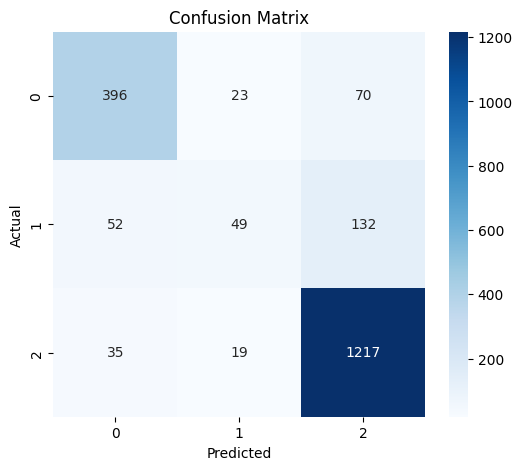

In [53]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()


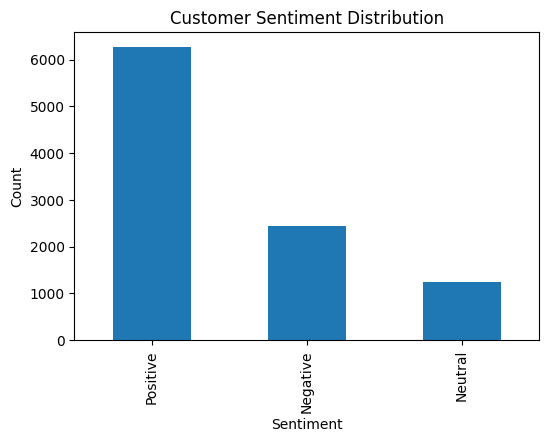

In [54]:
plt.figure(figsize=(6,4))

df["Sentiment"].value_counts().plot(kind="bar")

plt.title("Customer Sentiment Distribution")

plt.xlabel("Sentiment")

plt.ylabel("Count")

plt.show()

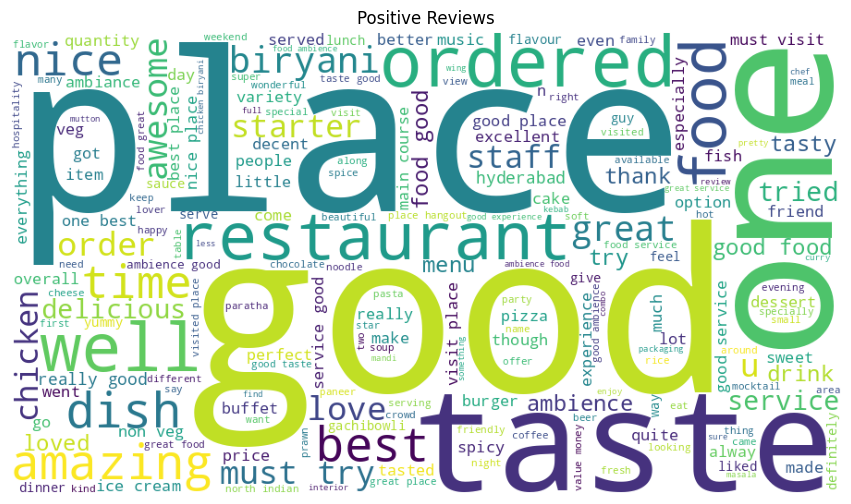

In [55]:
positive = " ".join(
    df[df["Sentiment"]=="Positive"]["Clean_Review"]
)

wordcloud = WordCloud(
    width=900,
    height=500,
    background_color="white"
).generate(positive)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Positive Reviews")

plt.show()

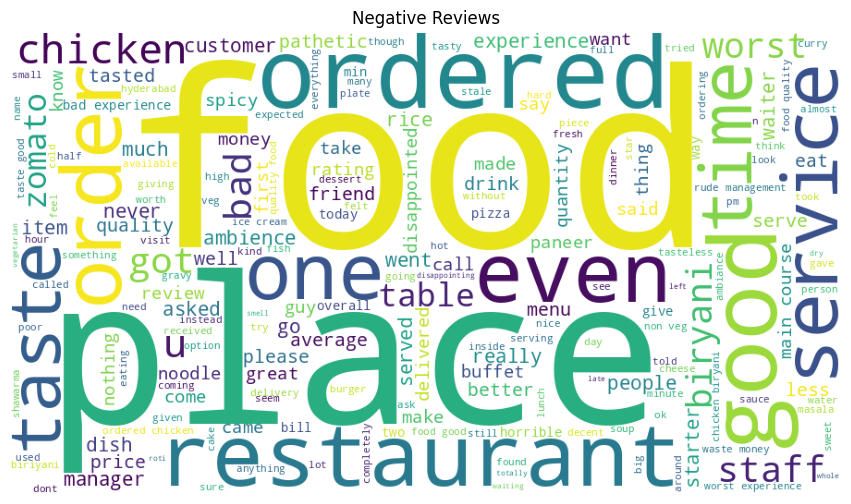

In [56]:
negative = " ".join(
    df[df["Sentiment"]=="Negative"]["Clean_Review"]
)

wordcloud = WordCloud(
    width=900,
    height=500,
    background_color="white"
).generate(negative)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Negative Reviews")

plt.show()

In [57]:
issues = [
    "delivery",
    "late",
    "cold",
    "price",
    "packaging",
    "service",
    "staff",
    "wait",
    "taste",
    "refund",
    "quality",
    "food",
    "clean",
    "manager"
]

issue_count = {}

for issue in issues:
    issue_count[issue] = df["Clean_Review"].str.contains(issue).sum()

issue_df = pd.DataFrame(
    issue_count.items(),
    columns=["Issue","Count"]
)

issue_df.sort_values(by="Count", ascending=False)

,Issue,Count
11,food,4745
5,service,2722
8,taste,2275
6,staff,1263
10,quality,790
3,price,783
1,late,697
7,wait,528
0,delivery,480
2,cold,205


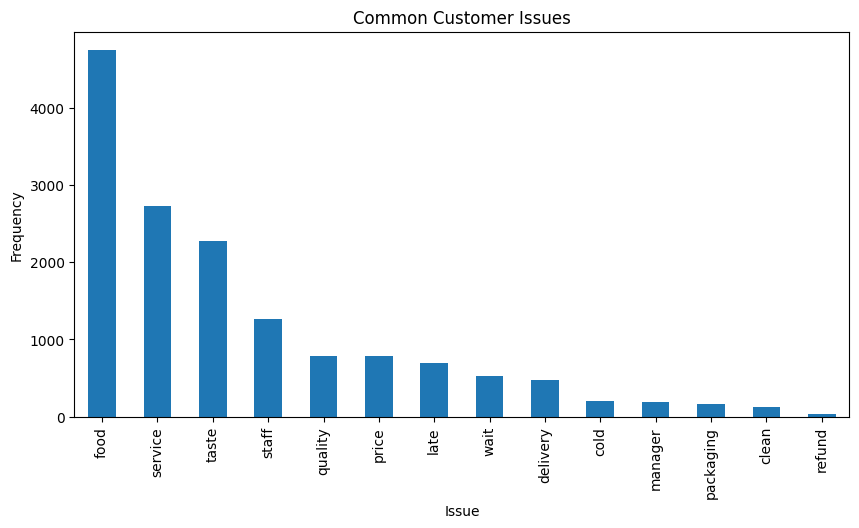

In [58]:
issue_df.sort_values(by="Count", ascending=False).plot(
    x="Issue",
    y="Count",
    kind="bar",
    figsize=(10,5),
    legend=False
)

plt.title("Common Customer Issues")

plt.ylabel("Frequency")

plt.show()

In [59]:
review = input("Enter Restaurant Review: ")

clean = preprocess(review)

vector = tfidf.transform([clean])

prediction = model.predict(vector)

print("Predicted Sentiment :", prediction[0])

Enter Restaurant Review: Good
Predicted Sentiment : Positive
